# Supplemental, find kappa for the chromatin

Code to compute the MG1 DG1 measure for finding the optimal kappa for the chromatin.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [353]:
from src.config import load_default_chrom_configs
from src.combined_chromatin_model import CombinedChromatinModel

config1, config2 = load_default_chrom_configs()

combined_model = CombinedChromatinModel(config1=config1, config2=config2)

chrom = 1
mnase_span = 45000, 46000

# Load window to deconvolve
combined_model.load_mnase_span(chrom, mnase_span)
combined_model.setup_deconv_model(copy_correct=False)


Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 999) to (16, 26, 100)
Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 999) to (15, 26, 100)
Loading copy correction N, Fr, B from output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr


In [355]:
combined_model.deconvolve(gamma=0.07, kappa=0.0, eta=0)

0/2600 - 00:00:00.000
500/2600 - 00:00:15.374
1000/2600 - 00:01:34.911
1500/2600 - 00:03:36.223
2000/2600 - 00:05:24.320
2500/2600 - 00:06:59.292
Completed - 00:07:08.622


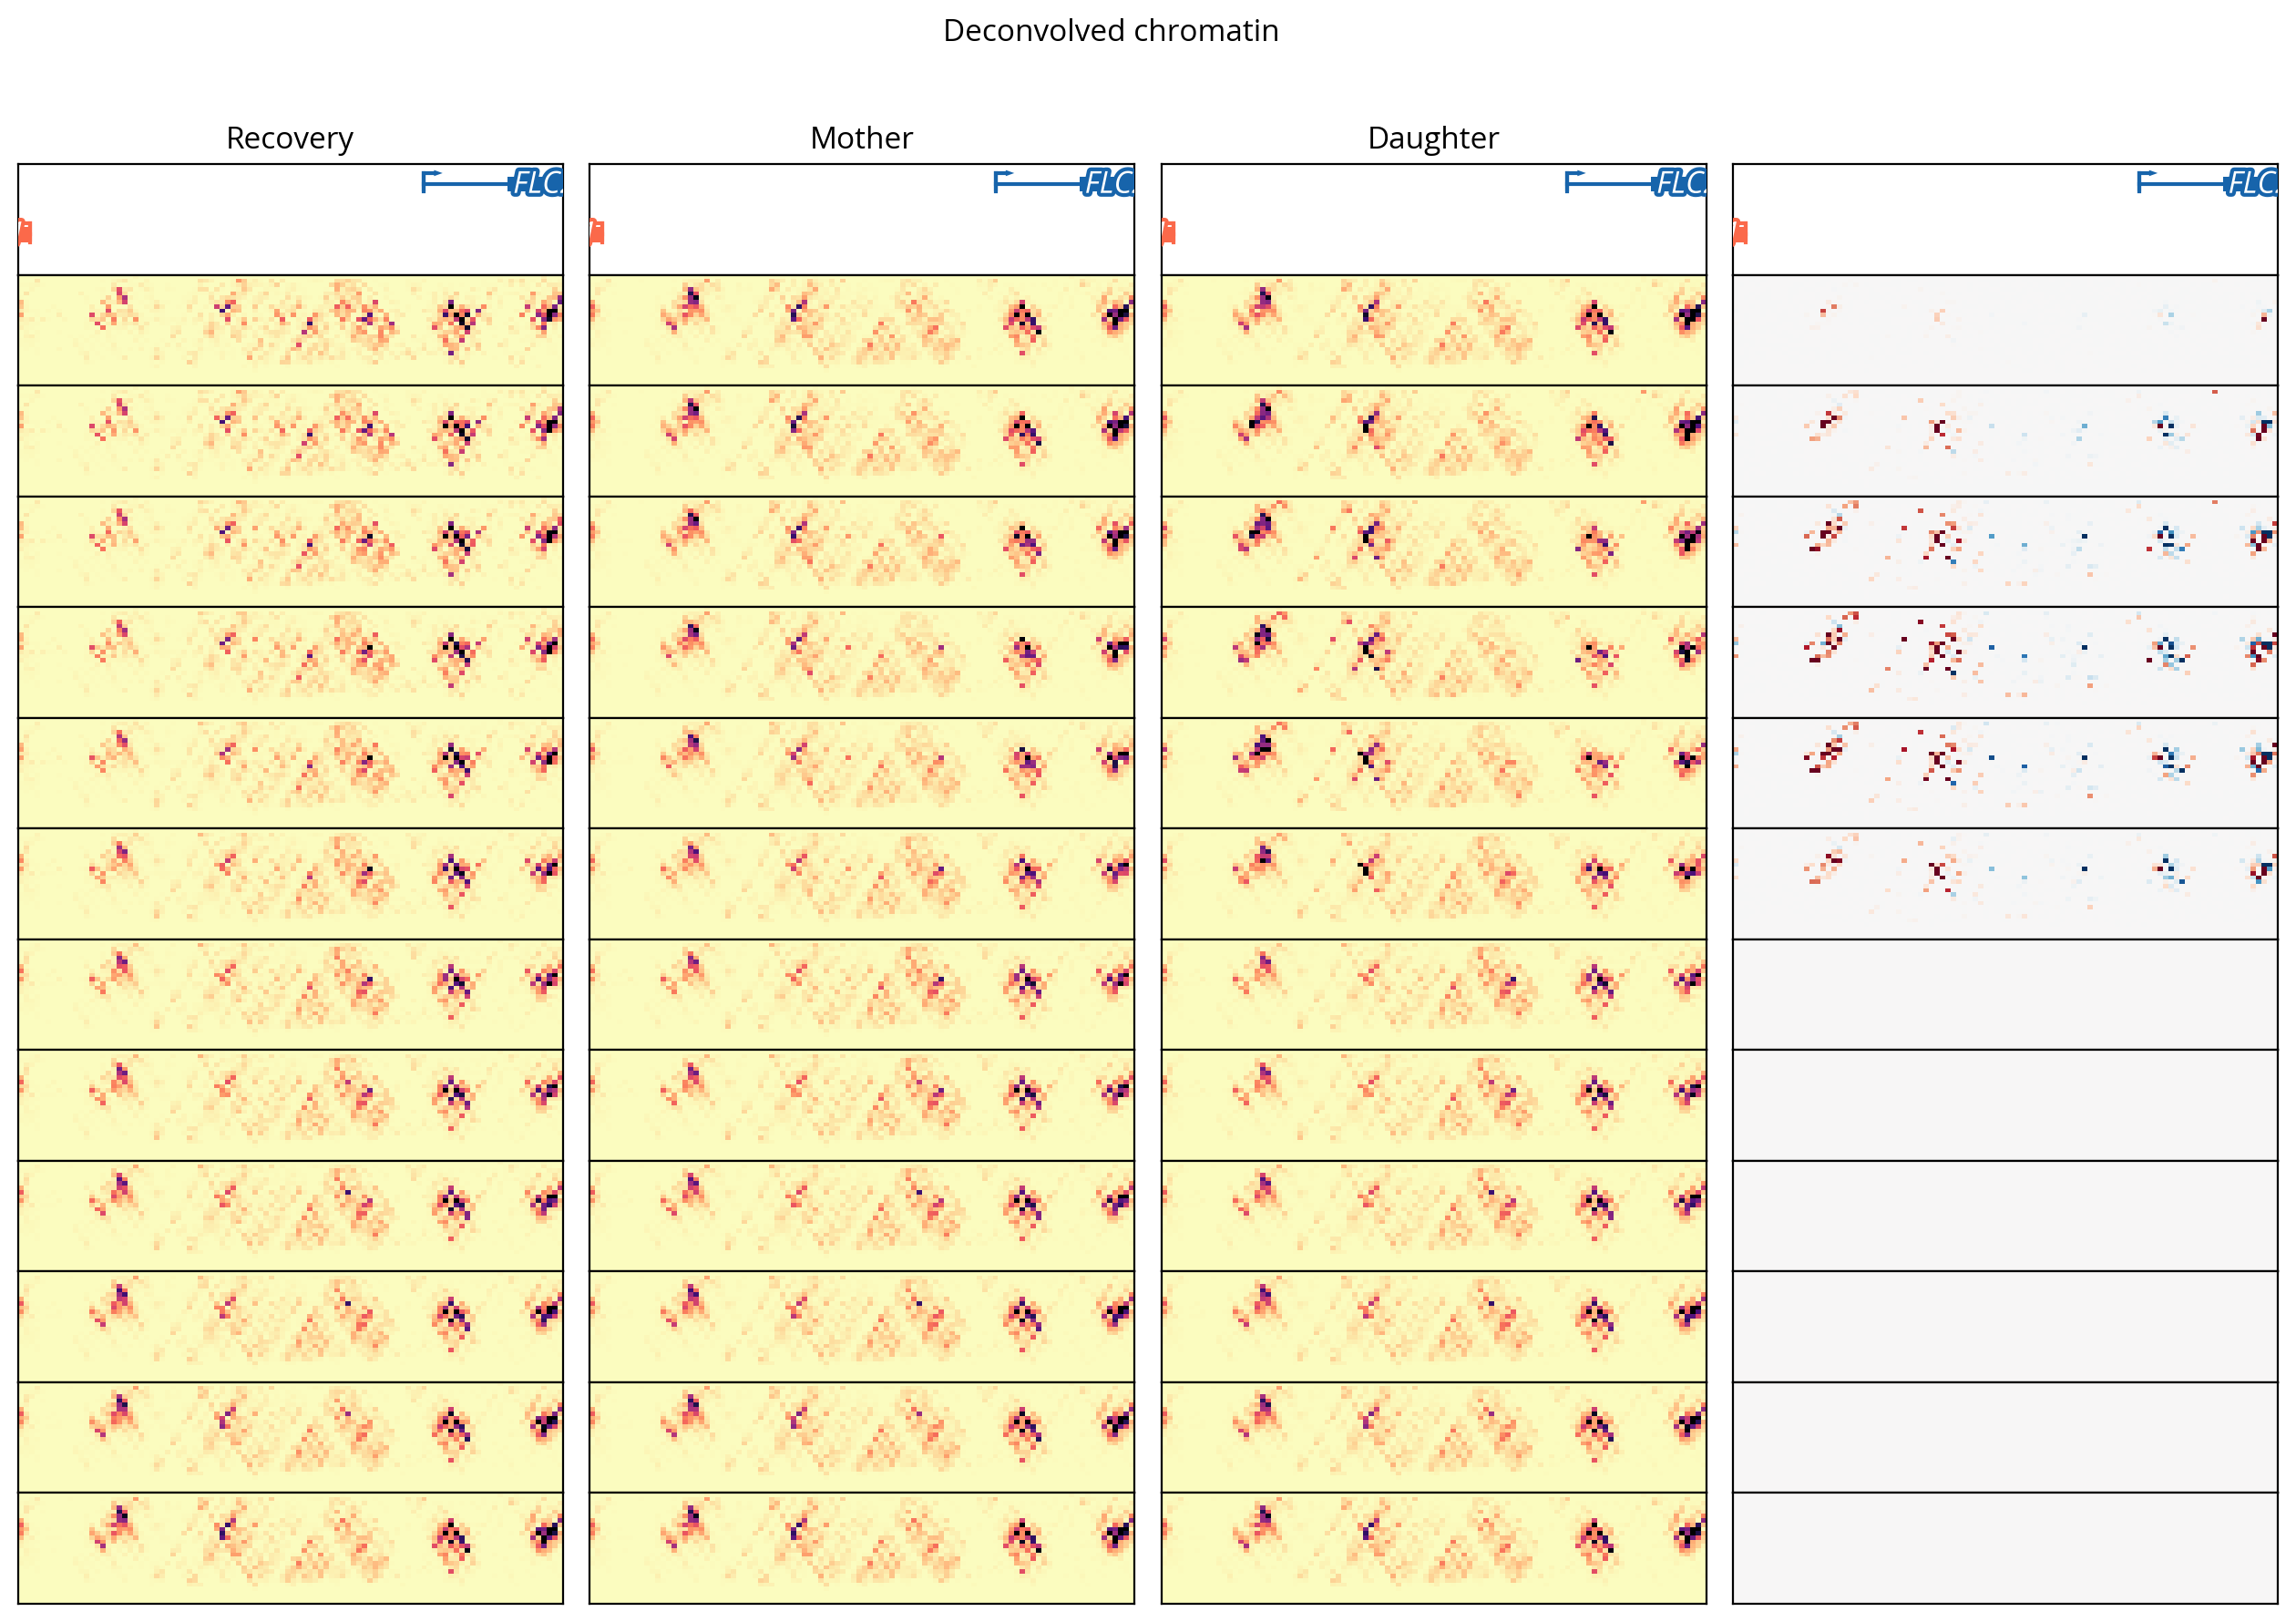

In [356]:
combined_model.plot_branches(figsize=(16, 10))

In [357]:
from src.dg1_mg1_island_analysis import ChromatinOccupancyIslandDetector

# Usage:
detector = ChromatinOccupancyIslandDetector(config1, config2, 
    combined_model.solver.F)
detector.step1_preprocess_data(min_occupancy=1e-3)
_ = detector.step2_analyze_distribution(std_multiplier=1, plot=False)

F_imgs shape: (257, 26, 100)
MG1 shape: (64, 26, 100)
DG1 shape: (64, 26, 100)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 100), DG1: (26, 100)
Total positions: 2600
Filtered positions: 1771
Filtered percentage: 68.1%
=== Step 2: Distribution Analysis ===
Mean difference: 0.236
Std difference: 3.514
Threshold range: [-3.278, 3.750]


=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 99
Detected 6 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 32
Negative outlier pixels: 13
Detected 3 positive islands
Detected 2 negative islands
Mother/Daughter pixels: 36
Remaining pixels after M/D subtraction: 66
Detected 6 unchanging islands


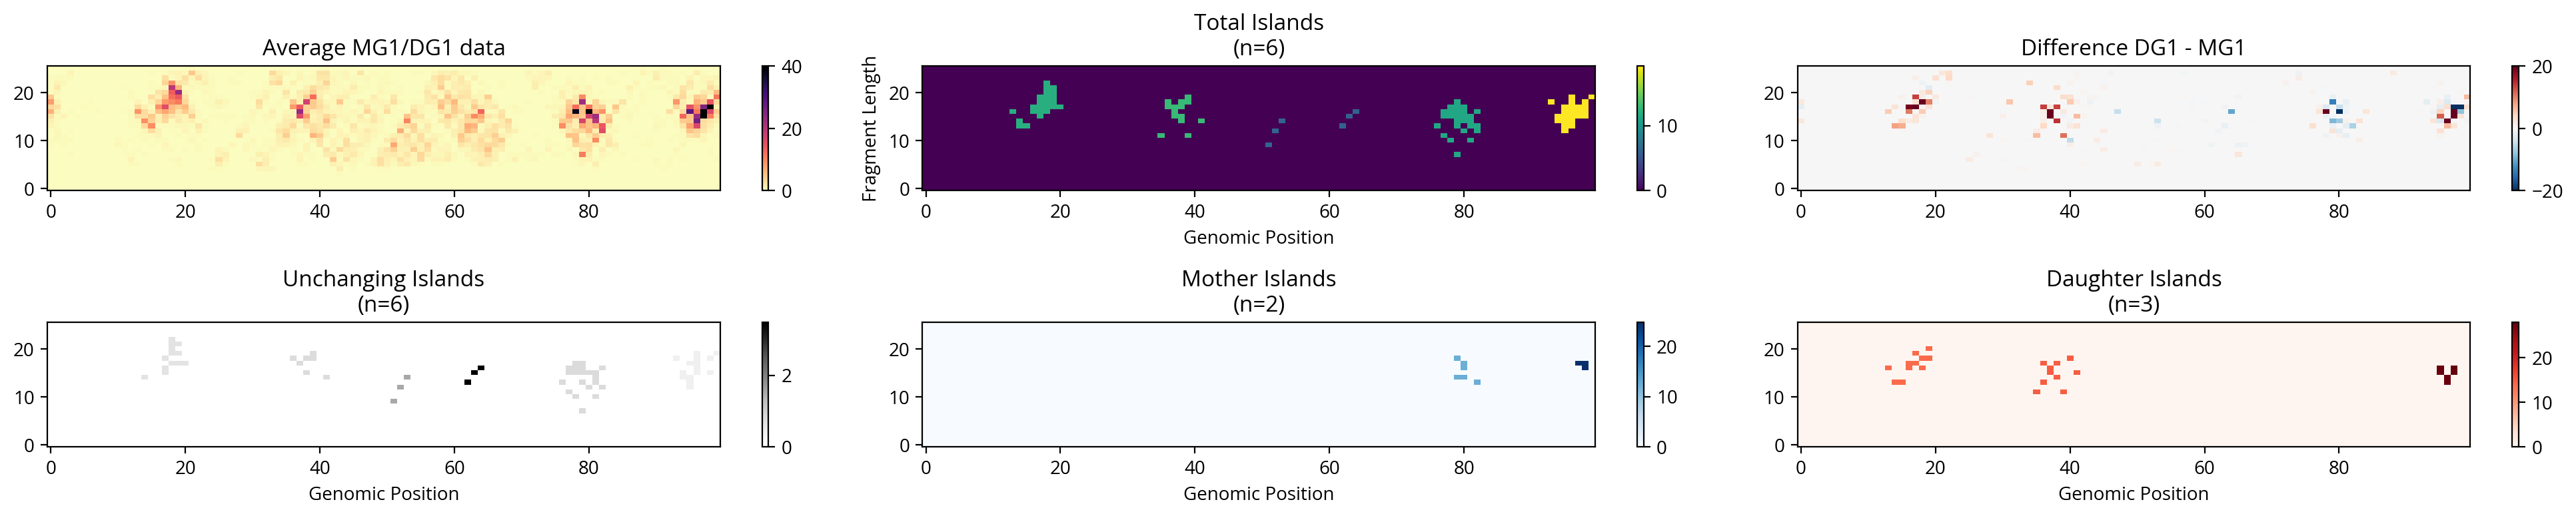

In [358]:
all_islands = detector.detect_all_island_types(max_distance=4, min_size=3,
    occupancy_threshold=5)
detector.plot_all_islands_overview()

In [359]:
_ = detector.comprehensive_summary()


CHROMATIN LANDSCAPE COMPOSITION ANALYSIS

🧬 CHROMATIN BREAKDOWN:
   Total chromatin regions detected: 6 islands
   Genome coverage by chromatin: 3.7%

📊 CHROMATIN COMPOSITION (by island count):
   • Mother-specific:    18.2% (2 islands)
   • Daughter-specific:  27.3% (3 islands)
   • Unchanging:         54.5% (6 islands)

📊 CHROMATIN COMPOSITION (by pixel coverage):
   • Mother-specific:    9.2%
   • Daughter-specific:  27.6%
   • Unchanging:         63.3%


In [360]:
dynamic_percent = detector.composition_stats['dynamics']['dynamic_percent']
print(f"{dynamic_percent:.2f}% "
        "of the chromatin is mother or daughter-specific")

36.73% of the chromatin is mother or daughter-specific


In [361]:
kappa_min = 1e-5
kappa_max = 1
num_kappas = 24

log_kp_start, log_kp_end = np.log2(kappa_min), np.log2(kappa_max)
log_kp_vals = np.linspace(log_kp_start, log_kp_end, num_kappas)
kappa_array = 2**log_kp_vals

In [362]:
from src.timer import Timer

timer = Timer()

# Now let's try a set of kappa values and observe how the metric changes
dynamic_percentages = []
sns = []
rns = []

for i, kappa in enumerate(kappa_array):
    
    combined_model.deconvolve(gamma=0.07, kappa=kappa, eta=0)
    F = combined_model.solver.F
    
    from src.dg1_mg1_island_analysis import ChromatinOccupancyIslandDetector

    detector = ChromatinOccupancyIslandDetector(config1, config2, F)
    detector.step1_preprocess_data(min_occupancy=1e-3)
    _ = detector.step2_analyze_distribution(std_multiplier=1, plot=False)
    all_islands = detector.detect_all_island_types(max_distance=4, min_size=3,
        occupancy_threshold=5)
    
    # Run deconvolution with kappa
    # Run your island detection pipeline
    stats = detector.calculate_chromatin_composition()
    dynamic_percentages.append(stats['dynamics']['dynamic_percent'])
    sns.append(combined_model.solver.sn)
    rns.append(combined_model.solver.rn)

    timer.print_time(f"{i}/{len(kappa_array)}")
    

0/2600 - 00:00:00.001
500/2600 - 00:00:19.013
1000/2600 - 00:01:44.633
1500/2600 - 00:03:19.274
2000/2600 - 00:04:59.312
2500/2600 - 00:06:32.563
Completed - 00:06:40.981
F_imgs shape: (257, 26, 100)
MG1 shape: (64, 26, 100)
DG1 shape: (64, 26, 100)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 100), DG1: (26, 100)
Total positions: 2600
Filtered positions: 1771
Filtered percentage: 68.1%
=== Step 2: Distribution Analysis ===
Mean difference: 0.236
Std difference: 3.513
Threshold range: [-3.277, 3.749]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 99
Detected 6 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 32
Negative outlier pixels: 13
Detected 3 positive islands
Detected 2 negative islands
Mother/Daughter pixels: 36
Remaining pixels after M/D subtraction: 66
Detected 6 unchanging islands
0/2600 - 00:00

500/2600 - 00:00:14.648
1000/2600 - 00:01:34.649
1500/2600 - 00:02:58.955
2000/2600 - 00:04:25.669
2500/2600 - 00:05:47.231
Completed - 00:05:55.143
F_imgs shape: (257, 26, 100)
MG1 shape: (64, 26, 100)
DG1 shape: (64, 26, 100)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 100), DG1: (26, 100)
Total positions: 2600
Filtered positions: 1771
Filtered percentage: 68.1%
=== Step 2: Distribution Analysis ===
Mean difference: 0.079
Std difference: 2.216
Threshold range: [-2.137, 2.295]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 100
Detected 6 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 10
Negative outlier pixels: 4
Detected 2 positive islands
Detected 0 negative islands
Mother/Daughter pixels: 7
Remaining pixels after M/D subtraction: 93
Detected 6 unchanging islands
0/2600 - 00:00:00.000
500/2600 - 00:0

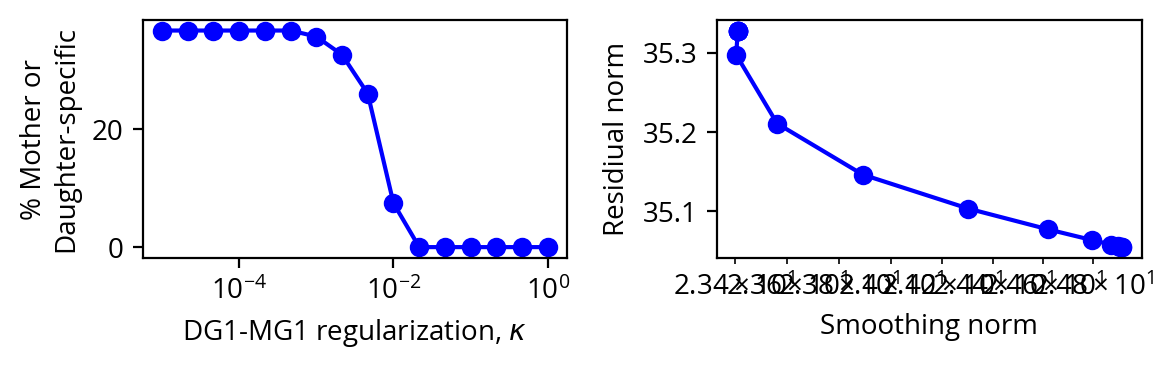

In [381]:
plt.figure(figsize=(6, 2))
plt.subplot(1, 2, 1)
# Plot elbow curve
plt.plot(kappa_array, dynamic_percentages, 'o-b')
plt.xscale('log')
plt.xlabel('DG1-MG1 regularization, $\\kappa$')
plt.ylabel('% Mother or\nDaughter-specific')

# Keep trakc of rn and sn as well, and observe how kappa affects these values
# I expect low kappa can contribute to poor smoothing. and we need kappa to be high enough
# to stabilize the solution as well.
plt.subplot(1, 2, 2)
plt.plot(sns, rns, 'o-b')
plt.xscale('log')
plt.xlabel("Smoothing norm")
plt.ylabel("Residiual norm")

plt.tight_layout()

In [371]:
kappa_results_df = pd.DataFrame({
    'm_d_perc': dynamic_percentages,
    'rn': rns,
    'sn': sns,
}, index=kappa_array)
kappa_results_df.index.name = 'kappa'
kappa_results_df

,m_d_perc,rn,sn
kappa,,,
0.000010,36.734694,35.055075,24.917965
0.000022,36.734694,35.055265,24.915258
0.000046,36.734694,35.055652,24.909758
0.000100,36.734694,35.056407,24.899086
0.000215,36.734694,35.058355,24.871888
0.000464,36.734694,35.063889,24.796708
0.001000,35.714286,35.077291,24.621426
0.002154,32.631579,35.103496,24.304015
0.004642,26.041667,35.146348,23.891037


In [ ]:
optimizer = ChromatinKappaOptimizer(output_dir, save_dir, gamma=0.07)
optimizer.set_chromosome_span(1, (45000, 46000))

# This now runs the focused search instead of broad sweep
optimal_kappa, results_df = optimizer.find_optimal_kappa_focused(
    kappa_min=1e-5, 
    kappa_max=1.0,
    verbose=True,
    save_results=True
)

In [383]:
from src.chromatin_find_kappa import ChromatinKappaOptimizer

# Initialize for a specific gamma value
optimizer = ChromatinKappaOptimizer(
    output_dir="output/draft3_run/",
    save_dir="output/draft3_run/find_kappa_chromatin",
    gamma=0.07
)

# Run analysis on different genomic windows
windows = [(1, (45000, 45200)), (2, (100000, 100200))]

for chrom, span in windows:
    optimizer.set_chromosome_span(chrom, span)
    results = optimizer.find_optimal_kappa_focused(
    kappa_min=1e-5, 
    kappa_max=1.0,
    verbose=True,
    save_results=True)


Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 199) to (16, 26, 20)
Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 199) to (15, 26, 20)
Loading copy correction N, Fr, B from output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
Running focused kappa optimization on chr1:45000-45200
Using gamma=0.07
Step 1: Calculating dynamic 

500/520 - 00:00:59.579
Completed - 00:01:00.226
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 314
Filtered percentage: 60.4%
=== Step 2: Distribution Analysis ===
Mean difference: 0.022
Std difference: 0.364
Threshold range: [-0.342, 0.386]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 34
Detected 2 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 4
Negative outlier pixels: 3
Detected 1 positive islands
Detected 1 negative islands
Mother/Daughter pixels: 7
Remaining pixels after M/D subtraction: 29
Detected 2 unchanging islands
		κ: 0.00782242	dynamics: 19.444%	rn: 51.5007	sn: 26.6098
0/520 - 00:00:00.000
500/520 - 00:01:00.949
Completed - 00:01:01.592
F_imgs shape: (257, 

500/520 - 00:00:58.137
Completed - 00:00:58.753
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 314
Filtered percentage: 60.4%
=== Step 2: Distribution Analysis ===
Mean difference: 0.137
Std difference: 1.810
Threshold range: [-1.673, 1.947]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 34
Detected 2 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 13
Negative outlier pixels: 6
Detected 1 positive islands
Detected 1 negative islands
Mother/Daughter pixels: 16
Remaining pixels after M/D subtraction: 23
Detected 2 unchanging islands
		κ: 0.0011544	dynamics: 41.026%	rn: 51.4372	sn: 26.7589
0/520 - 00:00:00.000
500/520 - 00:00:58.396
Completed - 00:00:59.009
F_imgs shape: (257,

500/520 - 00:01:01.204
Completed - 00:01:01.847
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 314
Filtered percentage: 60.4%
=== Step 2: Distribution Analysis ===
Mean difference: -0.000
Std difference: 0.000
Threshold range: [-0.100, 0.100]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 34
Detected 2 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 0
Negative outlier pixels: 0
Detected 0 positive islands
Detected 0 negative islands
Mother/Daughter pixels: 0
Remaining pixels after M/D subtraction: 34
Detected 2 unchanging islands
		κ: 0.0323716	dynamics: 0.000%	rn: 51.5307	sn: 26.4653
0/520 - 00:00:00.000
500/520 - 00:01:01.346
Completed - 00:01:02.021
F_imgs shape: (257, 2

500/520 - 00:00:59.649
Completed - 00:01:00.269
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 314
Filtered percentage: 60.4%
=== Step 2: Distribution Analysis ===
Mean difference: 0.003
Std difference: 0.093
Threshold range: [-0.097, 0.103]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 34
Detected 2 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 2
Negative outlier pixels: 3
Detected 0 positive islands
Detected 1 negative islands
Mother/Daughter pixels: 3
Remaining pixels after M/D subtraction: 32
Detected 2 unchanging islands
		κ: 0.0110949	dynamics: 8.571%	rn: 51.5129	sn: 26.6102
0/520 - 00:00:00.000
500/520 - 00:00:59.422
Completed - 00:01:00.049
F_imgs shape: (257, 26

...

500/520 - 00:01:05.793
Completed - 00:01:07.028
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 359
Filtered percentage: 69.0%
=== Step 2: Distribution Analysis ===
Mean difference: 0.020
Std difference: 0.784
Threshold range: [-0.764, 0.805]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 25
Detected 1 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 5
Negative outlier pixels: 2
Detected 1 positive islands
Detected 0 negative islands
Mother/Daughter pixels: 3
Remaining pixels after M/D subtraction: 23
Detected 1 unchanging islands
		κ: 0.00782242	dynamics: 11.538%	rn: 41.3872	sn: 26.4840
0/520 - 00:00:00.000
500/520 - 00:01:05.095
Completed - 00:01:06.333
F_imgs shape: (257, 

500/520 - 00:01:05.167
Completed - 00:01:06.402
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 359
Filtered percentage: 69.0%
=== Step 2: Distribution Analysis ===
Mean difference: 0.068
Std difference: 1.215
Threshold range: [-1.147, 1.283]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 25
Detected 1 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 11
Negative outlier pixels: 8
Detected 1 positive islands
Detected 1 negative islands
Mother/Daughter pixels: 18
Remaining pixels after M/D subtraction: 11
Detected 1 unchanging islands
		κ: 0.00139854	dynamics: 62.069%	rn: 41.3187	sn: 26.9862
0/520 - 00:00:00.000
500/520 - 00:01:04.531
Completed - 00:01:05.789
F_imgs shape: (257

500/520 - 00:01:05.278
Completed - 00:01:06.545
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 359
Filtered percentage: 69.0%
=== Step 2: Distribution Analysis ===
Mean difference: -0.000
Std difference: 0.000
Threshold range: [-0.100, 0.100]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 25
Detected 1 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 0
Negative outlier pixels: 0
Detected 0 positive islands
Detected 0 negative islands
Mother/Daughter pixels: 0
Remaining pixels after M/D subtraction: 25
Detected 1 unchanging islands
		κ: 0.0326164	dynamics: 0.000%	rn: 41.4153	sn: 26.7924
0/520 - 00:00:00.000
500/520 - 00:01:05.780
Completed - 00:01:07.019
F_imgs shape: (257, 2

500/520 - 00:01:04.780
Completed - 00:01:06.018
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 359
Filtered percentage: 69.0%
=== Step 2: Distribution Analysis ===
Mean difference: -0.011
Std difference: 0.589
Threshold range: [-0.600, 0.579]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 25
Detected 1 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 4
Negative outlier pixels: 2
Detected 1 positive islands
Detected 0 negative islands
Mother/Daughter pixels: 3
Remaining pixels after M/D subtraction: 23
Detected 1 unchanging islands
		κ: 0.00963858	dynamics: 11.538%	rn: 41.3951	sn: 26.5653
0/520 - 00:00:00.000
500/520 - 00:01:04.382
Completed - 00:01:05.613
F_imgs shape: (257,

KeyboardInterrupt: 

Optimal:
	gamma:	0.049
	kappa:	0.013
	eta:	0.264


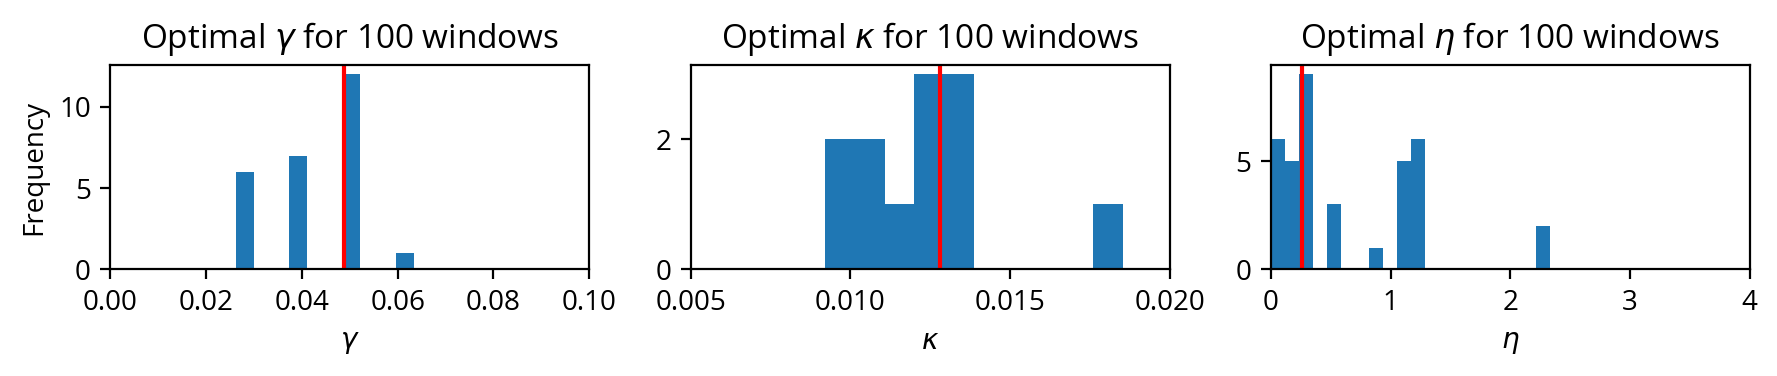

In [385]:
from pipeline.run_pipeline import run_gamma_kappa_eta_summary

run_gamma_kappa_eta_summary('output/draft3_run/')
